## Экстрактим фичи из картинок при помощи [SIFT](https://docs.opencv.org/4.x/da/df5/tutorial_py_sift_intro.html)

In [1]:
import sys
sys.path.append('../..')

%load_ext autoreload
%autoreload 2

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
from src.data.utils.eda_utils import directory_to_dataframe
from src.model.feature_extraction import extract_hog_features


In [4]:
path_to_train_dataset = Path('../../data/02_intermediate/sneakers-dataset')
path_to_test_dataset = Path("../../data/01_raw/sneakers-dataset")

In [6]:
train = directory_to_dataframe(path_to_train_dataset)

In [7]:
test = pd.read_csv('../../data/01_raw/test_images.csv')

In [8]:
train.set_index('path', inplace=True)
test.set_index('path', inplace=True)

In [11]:
import cv2 as cv

img_path = 'nike_dunk_low/0010.jpg'
img = cv.imread(path_to_train_dataset / img_path, cv.IMREAD_GRAYSCALE)
img

array([[245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       ...,
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245],
       [245, 245, 245, ..., 245, 245, 245]], shape=(140, 140), dtype=uint8)

In [12]:
pd.Series(extract_hog_features(img)).describe()

count    1764.000000
mean        0.071707
std         0.123203
min         0.000000
25%         0.000000
50%         0.003526
75%         0.090410
max         0.722027
dtype: float64

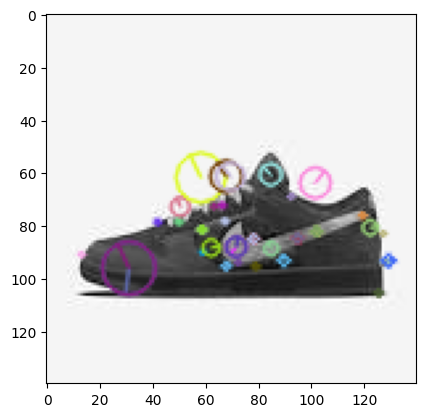

In [13]:
# Для каждого изображения в датафрейме считаем SIFT
sift = cv.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)
img_with_keypoints = cv.drawKeypoints(img, keypoints, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_with_keypoints)

In [14]:
feature_df = []
for img_path in train.index:
    img = cv.imread(path_to_train_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    feature_df.append(descriptors)
feature_df = pd.concat(feature_df)
feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,99.0,138.0,5.0,2.0,30.0,48.0,2.0,1.0,34.0,125.0,...,1.0,6.0,18.0,3.0,0.0,0.0,0.0,0.0,0.0,reebok_classic_leather/0081_1.jpg
1,0.0,1.0,9.0,13.0,4.0,20.0,6.0,0.0,1.0,4.0,...,66.0,0.0,0.0,2.0,89.0,60.0,10.0,8.0,1.0,reebok_classic_leather/0081_1.jpg
2,31.0,73.0,133.0,45.0,4.0,0.0,0.0,14.0,20.0,96.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,reebok_classic_leather/0081_1.jpg
3,23.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,134.0,17.0,...,0.0,1.0,16.0,77.0,7.0,1.0,0.0,0.0,0.0,reebok_classic_leather/0081_1.jpg
4,1.0,2.0,81.0,102.0,4.0,7.0,40.0,13.0,13.0,25.0,...,34.0,8.0,29.0,37.0,7.0,0.0,0.0,0.0,1.0,reebok_classic_leather/0081_1.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,0.0,0.0,0.0,0.0,0.0,0.0,53.0,115.0,9.0,0.0,...,0.0,58.0,11.0,0.0,0.0,1.0,4.0,0.0,1.0,nike_air_max_97/0011_0.jpg
159,73.0,40.0,0.0,0.0,7.0,1.0,0.0,0.0,7.0,4.0,...,1.0,2.0,71.0,136.0,13.0,1.0,0.0,0.0,0.0,nike_air_max_97/0011_0.jpg
160,32.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,157.0,0.0,...,0.0,0.0,11.0,15.0,0.0,0.0,0.0,0.0,0.0,nike_air_max_97/0011_0.jpg
161,37.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,156.0,1.0,...,0.0,0.0,15.0,57.0,1.0,0.0,0.0,0.0,0.0,nike_air_max_97/0011_0.jpg


In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

feature_df[list(range(128))] = scaler.fit_transform(feature_df[list(range(128))])
n_feats = 200
clustering = KMeans(n_feats)
clustering.fit(feature_df[list(range(128))])
feature_df['cluster_feat'] = clustering.predict(feature_df[list(range(128))]).astype(str)

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/a.r.makarenko/Documents/hse/sneake

In [16]:
test_feature_df = []
for img_path in test.index:
    img = cv.imread(path_to_test_dataset / img_path, cv.IMREAD_GRAYSCALE)
    sift = cv.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(img, None)
    descriptors = pd.DataFrame(descriptors)
    descriptors['path'] = img_path
    test_feature_df.append(descriptors)
test_feature_df = pd.concat(test_feature_df)
test_feature_df

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,path
0,33.0,19.0,7.0,3.0,19.0,16.0,27.0,22.0,4.0,3.0,...,37.0,0.0,1.0,0.0,0.0,30.0,9.0,0.0,1.0,adidas_forum_low/0026.jpg
1,1.0,7.0,6.0,0.0,4.0,39.0,27.0,3.0,48.0,1.0,...,4.0,54.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,adidas_forum_low/0026.jpg
2,0.0,0.0,154.0,154.0,0.0,0.0,0.0,1.0,2.0,1.0,...,10.0,2.0,4.0,18.0,13.0,6.0,5.0,38.0,62.0,adidas_forum_low/0026.jpg
3,148.0,23.0,0.0,0.0,0.0,0.0,24.0,38.0,148.0,42.0,...,14.0,7.0,11.0,8.0,4.0,20.0,1.0,0.0,3.0,adidas_forum_low/0026.jpg
4,0.0,3.0,34.0,8.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,35.0,93.0,3.0,0.0,0.0,0.0,0.0,0.0,adidas_forum_low/0026.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,1.0,0.0,0.0,0.0,6.0,32.0,42.0,30.0,7.0,0.0,...,19.0,5.0,0.0,0.0,0.0,0.0,0.0,6.0,15.0,nike_cortez/0130.jpg
13,0.0,98.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,...,131.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,nike_cortez/0130.jpg
14,0.0,1.0,31.0,141.0,7.0,0.0,0.0,0.0,89.0,67.0,...,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nike_cortez/0130.jpg
15,43.0,105.0,34.0,5.0,0.0,0.0,0.0,0.0,11.0,122.0,...,36.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,nike_cortez/0130.jpg


In [17]:
test_feature_df[list(range(128))] = scaler.transform(test_feature_df[list(range(128))])
test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/89987943.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_feature_df['cluster_feat'] = clustering.predict(test_feature_df[list(range(128))]).astype(str)


In [18]:
train[list(range(n_feats))] = 0
for i, row in tqdm(feature_df.iterrows()):
    train.loc[row['path'], int(row['cluster_feat'])] += 1
train

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/939111233.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[list(range(n_feats))] = 0
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/939111233.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[list(range(n_feats))] = 0
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/939111233.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
reebok_classic_leather/0081_1.jpg,reebok_classic_leather,0,0,0,0,0,1,0,0,1,...,1,0,0,1,0,0,1,0,0,0
reebok_classic_leather/0065.jpg,reebok_classic_leather,1,5,2,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,2
reebok_classic_leather/0061_4.jpg,reebok_classic_leather,3,0,0,6,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2,0
reebok_classic_leather/0059.jpg,reebok_classic_leather,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
reebok_classic_leather/0024_4.jpg,reebok_classic_leather,3,0,0,1,0,0,2,0,0,...,0,2,0,0,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_97/0097.jpg,nike_air_max_97,1,2,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
nike_air_max_97/0040.jpg,nike_air_max_97,0,3,0,0,0,0,0,0,1,...,0,0,1,1,0,0,1,0,0,0
nike_air_max_97/0054_0.jpg,nike_air_max_97,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,2,0


In [19]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf = TfidfTransformer()

train[list(range(n_feats))] = tfidf.fit_transform(train[list(range(n_feats))]).toarray()
train

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
reebok_classic_leather/0081_1.jpg,reebok_classic_leather,0.000000,0.000000,0.000000,0.000000,0.000000,0.152934,0.000000,0.000000,0.148478,...,0.164736,0.000000,0.000000,0.134715,0.000000,0.000000,0.146156,0.000000,0.000000,0.000000
reebok_classic_leather/0065.jpg,reebok_classic_leather,0.050130,0.337858,0.145243,0.000000,0.073398,0.000000,0.000000,0.000000,0.075014,...,0.000000,0.000000,0.000000,0.068061,0.000000,0.000000,0.000000,0.000000,0.000000,0.139691
reebok_classic_leather/0061_4.jpg,reebok_classic_leather,0.189941,0.000000,0.000000,0.469238,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.095327,0.000000,0.000000,0.177494,0.000000
reebok_classic_leather/0059.jpg,reebok_classic_leather,0.000000,0.000000,0.000000,0.000000,0.147586,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.079093,0.000000,0.000000
reebok_classic_leather/0024_4.jpg,reebok_classic_leather,0.257705,0.000000,0.000000,0.106107,0.000000,0.000000,0.219147,0.000000,0.000000,...,0.000000,0.254478,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.240817,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_97/0097.jpg,nike_air_max_97,0.052359,0.141153,0.000000,0.000000,0.076662,0.080702,0.000000,0.066598,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.072952
nike_air_max_97/0040.jpg,nike_air_max_97,0.000000,0.250619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.092741,...,0.000000,0.000000,0.094561,0.084144,0.000000,0.000000,0.091291,0.000000,0.000000,0.000000
nike_air_max_97/0054_0.jpg,nike_air_max_97,0.000000,0.000000,0.160974,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.178247,0.000000,0.000000,0.000000,0.311510,0.000000


In [20]:
test[list(range(n_feats))] = 0
for i, row in tqdm(test_feature_df.iterrows()):
    test.loc[row['path'], int(row['cluster_feat'])] += 1
test

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/3766615880.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[list(range(n_feats))] = 0
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/3766615880.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[list(range(n_feats))] = 0
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/3766615880.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,1,0,1,0,2,1,2,1,1,...,1,1,0,1,0,0,0,0,1,0
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,4,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
adidas_superstar/0028.jpg,adidas_superstar,1,0,2,0,2,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
adidas_forum_high/0091.jpg,adidas_forum_high,1,0,0,0,1,7,2,1,0,...,1,1,0,1,0,1,2,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,3,0,0,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
adidas_forum_high/0114.jpg,adidas_forum_high,4,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
test[list(range(n_feats))] = tfidf.transform(test[list(range(n_feats))]).toarray()
test

,sneaker_class,0,1,2,3,4,5,6,7,8,...,190,191,192,193,194,195,196,197,198,199
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0.050943,0.000000,0.073800,0.000000,0.149178,0.078520,0.129964,0.064797,0.076232,...,0.084579,0.075458,0.0,0.069165,0.00000,0.000000,0.000000,0.000000,0.071407,0.0
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0.357159,0.000000,0.000000,0.220584,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.140123,0.000000,0.0
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0.000000,0.161619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
adidas_superstar/0028.jpg,adidas_superstar,0.061417,0.000000,0.177945,0.000000,0.179846,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.090971,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
adidas_forum_high/0091.jpg,adidas_forum_high,0.031208,0.000000,0.000000,0.000000,0.045693,0.336704,0.079615,0.039694,0.000000,...,0.051813,0.046225,0.0,0.042370,0.00000,0.046987,0.091938,0.000000,0.087487,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0.318689,0.000000,0.000000,0.131217,0.000000,0.000000,0.271007,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
adidas_forum_high/0114.jpg,adidas_forum_high,0.340233,0.000000,0.000000,0.420261,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0


In [22]:
train = train.rename(columns=lambda col: f'sift_{col}' if isinstance(col, int) else col)
test = test.rename(columns=lambda col: f'sift_{col}' if isinstance(col, int) else col)

In [23]:
hog_scaler = StandardScaler()
X_hog_train = []
for img_path in tqdm(train.index):
    img = cv.imread(path_to_train_dataset / img_path, cv.IMREAD_GRAYSCALE)
    X_hog_train.append(extract_hog_features(img))
X_hog_train = np.array(X_hog_train)
train[[f'hog_{i}' for i in range(X_hog_train.shape[1])]] = hog_scaler.fit_transform(X_hog_train)
train

  0%|          | 0/20862 [00:00<?, ?it/s]

100%|██████████| 20862/20862 [00:04<00:00, 4776.98it/s]
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/43943286.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[[f'hog_{i}' for i in range(X_hog_train.shape[1])]] = hog_scaler.fit_transform(X_hog_train)
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/43943286.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[[f'hog_{i}' for i in range(X_hog_train.shape[1])]] = hog_scaler.fit_transform(X_hog_train)
/var/folders/t1/3rmgtp792xl3ffv_

,sneaker_class,sift_0,sift_1,sift_2,sift_3,sift_4,sift_5,sift_6,sift_7,sift_8,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
path,,,,,,,,,,,,,,,,,,,,,
reebok_classic_leather/0081_1.jpg,reebok_classic_leather,0.000000,0.000000,0.000000,0.000000,0.000000,0.152934,0.000000,0.000000,0.148478,...,0.518596,0.995297,-0.418057,-0.413761,1.467999,0.523513,-0.571148,-0.538872,-0.521033,0.553740
reebok_classic_leather/0065.jpg,reebok_classic_leather,0.050130,0.337858,0.145243,0.000000,0.073398,0.000000,0.000000,0.000000,0.075014,...,-0.803364,-0.902492,-0.719679,-0.822613,-0.831717,-1.251630,-0.608668,-0.538388,-0.521033,-0.872195
reebok_classic_leather/0061_4.jpg,reebok_classic_leather,0.189941,0.000000,0.000000,0.469238,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.478465,1.432625,1.811820,-0.315185,-0.836731,0.918252,1.446666,-0.167621,0.705900,1.490750
reebok_classic_leather/0059.jpg,reebok_classic_leather,0.000000,0.000000,0.000000,0.000000,0.147586,0.000000,0.000000,0.000000,0.000000,...,0.068181,0.819784,2.079988,0.659743,-0.688249,-1.053100,-0.334897,-0.330439,0.580818,0.710835
reebok_classic_leather/0024_4.jpg,reebok_classic_leather,0.257705,0.000000,0.000000,0.106107,0.000000,0.000000,0.219147,0.000000,0.000000,...,1.035012,1.193461,-0.598448,-0.424806,-0.817786,0.702379,-0.545721,-0.538872,-0.521033,1.249619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_max_97/0097.jpg,nike_air_max_97,0.052359,0.141153,0.000000,0.000000,0.076662,0.080702,0.000000,0.066598,0.000000,...,-0.824870,-0.286506,0.271898,0.520564,0.941061,0.117516,2.241045,2.773911,2.103014,-0.402720
nike_air_max_97/0040.jpg,nike_air_max_97,0.000000,0.250619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.092741,...,-0.845723,0.183445,2.332400,-0.310636,-0.781518,-1.140557,-0.584727,-0.441171,0.013709,-0.381993
nike_air_max_97/0054_0.jpg,nike_air_max_97,0.000000,0.000000,0.160974,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.438661,0.860605,-0.573457,0.147695,0.470893,0.401938,2.832939,0.679015,0.681358,0.273888


In [24]:
X_hog_test = []
for img_path in tqdm(test.index):
    img = cv.imread(path_to_test_dataset / img_path, cv.IMREAD_GRAYSCALE)
    X_hog_test.append(extract_hog_features(img))
X_hog_test = np.array(X_hog_test)
test[[f'hog_{i}' for i in range(X_hog_test.shape[1])]] = hog_scaler.transform(X_hog_test)
test

100%|██████████| 1160/1160 [00:00<00:00, 4551.73it/s]
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/251660989.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[[f'hog_{i}' for i in range(X_hog_test.shape[1])]] = hog_scaler.transform(X_hog_test)
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/251660989.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[[f'hog_{i}' for i in range(X_hog_test.shape[1])]] = hog_scaler.transform(X_hog_test)
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn

,sneaker_class,sift_0,sift_1,sift_2,sift_3,sift_4,sift_5,sift_6,sift_7,sift_8,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
path,,,,,,,,,,,,,,,,,,,,,
adidas_forum_low/0026.jpg,adidas_forum_low,0.050943,0.000000,0.073800,0.000000,0.149178,0.078520,0.129964,0.064797,0.076232,...,-0.729479,0.804615,2.056240,1.975738,-0.390908,-1.227834,-0.600526,-0.520697,-0.421164,-0.550892
nike_air_jordan_4/0078.jpg,nike_air_jordan_4,0.357159,0.000000,0.000000,0.220584,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.859290,0.205902,0.771547,0.060806,-0.339304,0.273919,0.123134,0.098645,0.090040,-0.215807
yeezy_boost_350_v2/0018.jpg,yeezy_boost_350_v2,0.000000,0.161619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.066461,-0.972054,-0.725511,-0.836140,-0.836731,-1.252247,-0.609487,-0.538872,-0.521033,-0.933712
adidas_superstar/0028.jpg,adidas_superstar,0.061417,0.000000,0.177945,0.000000,0.179846,0.000000,0.000000,0.000000,0.000000,...,-1.066461,-0.972054,-0.725511,-0.836140,-0.836731,-1.252247,-0.609487,-0.538872,-0.521033,-0.933712
adidas_forum_high/0091.jpg,adidas_forum_high,0.031208,0.000000,0.000000,0.000000,0.045693,0.336704,0.079615,0.039694,0.000000,...,1.060363,1.037564,1.491235,-0.235571,-0.467611,-1.057252,-0.393384,0.110715,1.039915,1.092439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nike_air_vapormax_flyknit/0010.jpg,nike_air_vapormax_flyknit,0.318689,0.000000,0.000000,0.131217,0.000000,0.000000,0.271007,0.000000,0.000000,...,-1.066461,-0.972054,-0.725511,-0.836140,-0.836731,-1.252247,-0.609487,-0.538872,-0.521033,-0.933712
nike_air_jordan_1_low/0015.jpg,nike_air_jordan_1_low,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.949409,-0.972054,-0.725511,-0.836140,-0.836731,-1.252247,-0.609487,-0.538872,-0.521033,-0.933712
adidas_forum_high/0114.jpg,adidas_forum_high,0.340233,0.000000,0.000000,0.420261,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.540632,-0.968562,-0.551484,-0.612021,0.961310,1.053301,-0.413593,-0.537622,-0.517641,-0.926012


In [25]:
from sklearn.svm import LinearSVC, SVC

svc = LinearSVC(loss='squared_hinge', C=1, random_state=42)
sift_feats = [col for col in train.columns if 'sift' in col]
svc.fit(train[sift_feats], train['sneaker_class'])

train['pred'] = svc.predict(train[sift_feats])
print(classification_report(train['sneaker_class'], train['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.35      0.43      0.39       534
                   adidas_forum_low       0.43      0.34      0.38       330
                     adidas_gazelle       0.36      0.45      0.40       534
                      adidas_nmd_r1       0.35      0.43      0.39       342
                       adidas_samba       0.37      0.38      0.37       264
                  adidas_stan_smith       0.26      0.28      0.27       534
                   adidas_superstar       0.37      0.56      0.45       336
                  adidas_ultraboost       0.39      0.36      0.37       534
                 asics_gel-lyte_iii       0.41      0.18      0.25       330
             converse_chuck_70_high       0.34      0.20      0.25       270
              converse_chuck_70_low       0.35      0.43      0.39       528
converse_chuck_taylor_all-star_high       0.45      0.75      0.56       27

/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/a.r.makarenko/Documents/hse/sneakers-hse/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/3270361431.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['pred'] = svc.predict(train[sift_feats])


In [26]:
svc = SVC(C=1, random_state=42)
hog_feats = [col for col in train.columns if 'hog' in col]
svc.fit(train[hog_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.25      0.37      0.30        30
                   adidas_forum_low       0.33      0.22      0.27        18
                     adidas_gazelle       0.38      0.30      0.33        30
                      adidas_nmd_r1       0.89      0.42      0.57        19
                       adidas_samba       0.33      0.21      0.26        14
                  adidas_stan_smith       0.28      0.41      0.33        29
                   adidas_superstar       0.56      0.26      0.36        19
                  adidas_ultraboost       0.58      0.60      0.59        30
                 asics_gel-lyte_iii       0.71      0.28      0.40        18
             converse_chuck_70_high       0.44      0.27      0.33        15
              converse_chuck_70_low       0.22      0.47      0.29        30
converse_chuck_taylor_all-star_high       0.38      0.33      0.36        1

/var/folders/t1/3rmgtp792xl3ffv_d2f7y7v40000gn/T/ipykernel_50485/497945233.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['pred'] = svc.predict(test[hog_feats])


In [27]:
svc = SVC(C=10, random_state=42, kernel='poly', degree=2, class_weight='balanced')

svc.fit(train[hog_feats + sift_feats], train['sneaker_class'])

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.29      0.40      0.34        30
                   adidas_forum_low       0.33      0.28      0.30        18
                     adidas_gazelle       0.56      0.30      0.39        30
                      adidas_nmd_r1       0.54      0.37      0.44        19
                       adidas_samba       0.50      0.29      0.36        14
                  adidas_stan_smith       0.19      0.31      0.23        29
                   adidas_superstar       0.83      0.26      0.40        19
                  adidas_ultraboost       0.52      0.50      0.51        30
                 asics_gel-lyte_iii       0.62      0.28      0.38        18
             converse_chuck_70_high       0.50      0.27      0.35        15
              converse_chuck_70_low       0.26      0.40      0.31        30
converse_chuck_taylor_all-star_high       0.40      0.27      0.32        1

## Балансирую обучающий датасет

In [28]:
from imblearn.under_sampling import NearMiss

undersampling = NearMiss(n_jobs=8)
X_train_resampled, y_train_resampled = undersampling.fit_resample(train[hog_feats + sift_feats], train['sneaker_class'])
X_train_resampled

,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,sift_190,sift_191,sift_192,sift_193,sift_194,sift_195,sift_196,sift_197,sift_198,sift_199
0,1.895904,-0.154754,-0.153541,-0.310519,1.550870,0.331123,0.270447,-0.315529,1.944106,1.799206,...,0.000000,0.000000,0.071917,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.767072,-0.584902,-0.641221,-0.564212,-0.770394,-0.518025,-0.511099,-0.499877,-0.756688,-0.867598,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-0.767072,-0.584902,-0.641221,-0.564212,-0.770394,-0.518025,-0.511099,-0.499877,-0.756688,-0.867598,...,0.200113,0.000000,0.000000,0.000000,0.000000,0.090738,0.000000,0.000000,0.084474,0.000000
3,-0.767072,-0.584902,-0.641221,-0.564212,-0.770394,-0.518025,-0.511099,-0.499877,-0.756688,-0.867598,...,0.241186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,-0.767072,-0.584902,-0.641221,-0.564212,-0.770394,-0.518025,-0.511099,-0.499877,-0.756688,-0.867598,...,0.000000,0.000000,0.106673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12931,-0.767072,-0.584902,-0.641221,-0.564212,-0.770394,-0.518025,-0.511099,-0.499877,-0.756688,-0.867598,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.075260,0.000000,0.000000,0.000000,0.069645
12932,-0.221355,-0.505875,-0.362170,-0.557484,0.912773,-0.518025,1.189389,0.074291,-0.203220,0.614483,...,0.000000,0.000000,0.000000,0.104258,0.000000,0.115618,0.000000,0.000000,0.000000,0.000000
12933,-0.365151,0.484299,0.282180,-0.066673,-0.543662,0.446780,0.355697,0.306832,-0.274691,-0.386756,...,0.067553,0.120536,0.000000,0.110484,0.065268,0.000000,0.119867,0.063852,0.000000,0.113381
12934,1.892102,-0.073396,0.642900,-0.215253,1.547556,-0.202765,-0.296144,-0.427298,1.940250,1.795398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.146314,0.095429,0.000000,0.000000,0.045133


In [31]:
svc = SVC(C=10, random_state=42, kernel='poly', degree=2, class_weight='balanced')

svc.fit(X_train_resampled, y_train_resampled)

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.31      0.30      0.31        30
                   adidas_forum_low       0.28      0.28      0.28        18
                     adidas_gazelle       0.58      0.23      0.33        30
                      adidas_nmd_r1       0.44      0.37      0.40        19
                       adidas_samba       0.50      0.36      0.42        14
                  adidas_stan_smith       0.25      0.24      0.25        29
                   adidas_superstar       0.31      0.21      0.25        19
                  adidas_ultraboost       0.79      0.37      0.50        30
                 asics_gel-lyte_iii       0.50      0.28      0.36        18
             converse_chuck_70_high       0.33      0.33      0.33        15
              converse_chuck_70_low       0.29      0.33      0.31        30
converse_chuck_taylor_all-star_high       0.24      0.27      0.25        1

In [33]:
undersampling = NearMiss(n_jobs=8, version=2)
X_train_resampled, y_train_resampled = undersampling.fit_resample(train[hog_feats + sift_feats], train['sneaker_class'])

svc = SVC(C=10, random_state=42, kernel='poly', degree=2, class_weight='balanced')

svc.fit(X_train_resampled, y_train_resampled)

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.48      0.33      0.39        30
                   adidas_forum_low       0.32      0.33      0.32        18
                     adidas_gazelle       0.33      0.23      0.27        30
                      adidas_nmd_r1       0.39      0.37      0.38        19
                       adidas_samba       0.33      0.36      0.34        14
                  adidas_stan_smith       0.32      0.38      0.35        29
                   adidas_superstar       0.36      0.21      0.27        19
                  adidas_ultraboost       0.48      0.43      0.46        30
                 asics_gel-lyte_iii       0.50      0.28      0.36        18
             converse_chuck_70_high       0.40      0.27      0.32        15
              converse_chuck_70_low       0.19      0.17      0.18        30
converse_chuck_taylor_all-star_high       0.31      0.27      0.29        1

In [34]:
from imblearn.under_sampling import RandomUnderSampler

undersampling = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampling.fit_resample(train[hog_feats + sift_feats], train['sneaker_class'])

svc = SVC(C=10, random_state=42, kernel='poly', degree=2, class_weight='balanced')

svc.fit(X_train_resampled, y_train_resampled)

test['pred'] = svc.predict(test[hog_feats + sift_feats])
print(classification_report(test['sneaker_class'], test['pred']))

                                     precision    recall  f1-score   support

                  adidas_forum_high       0.34      0.33      0.34        30
                   adidas_forum_low       0.29      0.28      0.29        18
                     adidas_gazelle       0.42      0.27      0.33        30
                      adidas_nmd_r1       0.56      0.47      0.51        19
                       adidas_samba       0.36      0.29      0.32        14
                  adidas_stan_smith       0.20      0.31      0.24        29
                   adidas_superstar       0.56      0.26      0.36        19
                  adidas_ultraboost       0.56      0.50      0.53        30
                 asics_gel-lyte_iii       0.62      0.28      0.38        18
             converse_chuck_70_high       0.33      0.20      0.25        15
              converse_chuck_70_low       0.24      0.33      0.28        30
converse_chuck_taylor_all-star_high       0.29      0.27      0.28        1